In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("/content/BankNote_Authentication.csv")
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [4]:
df.isnull()
df.isnull().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
class,0


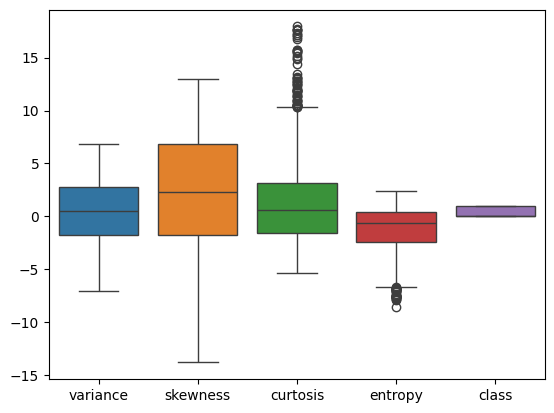

In [6]:
#outliers
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)
plt.show()

In [7]:
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR= Q3-Q1
outliers = df[~((df < (Q1 - 1.5 * IQR)) |
          (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [9]:
x=df[['variance','skewness','curtosis','entropy']]
y=df['class']

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x=scaler.fit_transform(x)

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,y, test_size=0.2,
    random_state=2
)

In [17]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

from sklearn.metrics import accuracy_score
accuracy= accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.9963636363636363


In [20]:
#SVM
from sklearn.svm import SVC
model= SVC()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 1.0


In [23]:
#DECISION TREE
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


Accuracy: 0.9818181818181818


In [28]:
#RANDOM FOREST---- comes under ensemble algo ****
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


Accuracy: 0.9890909090909091


In [29]:
#NAIVE BAYES
from sklearn.naive_bayes import GaussianNB
model= GaussianNB()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


Accuracy: 0.8109090909090909
